In [1]:
# !pip install torch torchvision --index-url https://download.pytorch.org/whl/cu117 --no-cache-dir --force-reinstall -q
# !pip install numpy==1.26.3 --no-deps

In [2]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import transforms
from datasets import load_dataset
from diffusers import AutoencoderKL


2025-03-27 09:42:27.141225: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-27 09:42:27.155716: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-27 09:42:27.160064: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-27 09:42:27.170798: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-27 09:42:27.958443: W tensorflow/compiler/tf2

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
from torchvision.models import vgg16
from torchvision.transforms import Normalize

# Load a pre-trained VGG model for perceptual loss
vgg = vgg16(pretrained=True).features[:16].to(device).eval()  # Only the first 16 layers
for param in vgg.parameters():
    param.requires_grad = False

# Normalize images for VGG
normalize = Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

def perceptual_loss(gen_imgs, real_imgs):
    # Normalize images for VGG
    gen_imgs = normalize(gen_imgs)
    real_imgs = normalize(real_imgs)

    # Extract features
    gen_features = vgg(gen_imgs)
    real_features = vgg(real_imgs)

    # Compute L1 or L2 loss between features
    return nn.functional.l1_loss(gen_features, real_features)

/opt/conda/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [5]:
class MyVAE(AutoencoderKL):
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)  # Gaussian noise
        noise = torch.randn_like(std) * 0.1  # Add extra noise
        z = mu + eps * std + noise
        return z

In [6]:
# Setup device and load pretrained VAE
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

vae = MyVAE.from_pretrained("KBlueLeaf/EQ-SDXL-VAE", latent_dim=128).to(device)

# Ensure all parameters are trainable
for param in vae.parameters():
    param.requires_grad = True

# Set the model to train mode
vae.train()
print("VAE is in train mode and ready for fine-tuning.")

Using device: cuda
VAE is in train mode and ready for fine-tuning.


In [7]:
# Load the dataset from Hugging Face Hub
dataset = load_dataset("Zaurall/floor_coverings_1", split="train")

In [8]:
# Filter dataset: keep only rows where the 'name1' field's id part is less than 60,000.
def filter_func(example):
    # Split the name (e.g. "00091_0") and take the first part as id
    id_str = example["name1"].split("_")[0]
    return int(id_str) < 60000

filtered_dataset = dataset.filter(filter_func)

In [9]:
# Split into train and test sets (here using a 90/10 split)
split_dataset = filtered_dataset.train_test_split(test_size=0.1, seed=42)
train_dataset = split_dataset["train"]
test_dataset = split_dataset["test"]

In [10]:
# Define a transform: adjust size and normalize as needed by your model.
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# Create a PyTorch Dataset that reads images from the HF dataset.
# Here we assume that "image2" is the target image (the generated parquet pattern).
class FloorCoveringsDataset(torch.utils.data.Dataset):
    def __init__(self, hf_dataset, transform):
        self.dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]
        image = sample["image2"]  # Use image2 as the reconstruction target.
        if self.transform:
            image = self.transform(image)
        return image

train_data = FloorCoveringsDataset(train_dataset, transform)
test_data = FloorCoveringsDataset(test_dataset, transform)


In [11]:
# Prepare DataLoaders
train_loader = DataLoader(train_data, batch_size=4, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_data, batch_size=4, pin_memory=True)

In [12]:
# Define optimizer and loss function.
optimizer = optim.AdamW(vae.parameters(), lr=1e-5)

mse = nn.MSELoss()

def vae_loss(recon, original, mu, logvar):
    # Reconstruction loss (MSE)
    mse_loss = mse(recon, original)
    
    # Perceptual loss
    perceptual_loss_value = perceptual_loss(recon, original)
    
    # Total loss
    total_loss = 0.2 * mse_loss + 0.8 * perceptual_loss_value  # Adjust weight as needed
    return total_loss

# Training loop
num_epochs = 2

In [13]:
from tqdm import tqdm

# Initialize variables for tracking the best loss
best_loss = float("inf")
best_model_weights = None

for epoch in range(num_epochs):
    running_loss = 0.0
    
    # Wrap the train_loader with tqdm for a progress bar
    train_loader_tqdm = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)
    
    for batch in train_loader_tqdm:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        # Encode the input image into the latent space
        latent_dist = vae.encode(batch).latent_dist
        mu, logvar = latent_dist.mean, latent_dist.logvar
        latents = vae.reparameterize(mu, logvar)
        
        # Decode the latent representation back into image space
        recon = vae.decode(latents).sample
        
        # Compute the reconstruction loss
        loss = vae_loss(recon, batch, mu, logvar)
        loss.backward()
        
		# Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(vae.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        # Update the running loss
        running_loss += loss.item()
        
        # Update the progress bar description with the current batch loss
        train_loader_tqdm.set_postfix(loss=loss.item())
    
    # Calculate the average loss for the epoch
    avg_loss = running_loss / len(train_loader)         
    
    # Print the average loss for the epoch
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

Epoch 1/2, Loss: 0.3417


Epoch 2/2, Loss: 0.3265


In [14]:
vae.save_pretrained(f"../models/vae/finetuned_vae_percept_2")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Average Test Loss: 0.0024


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


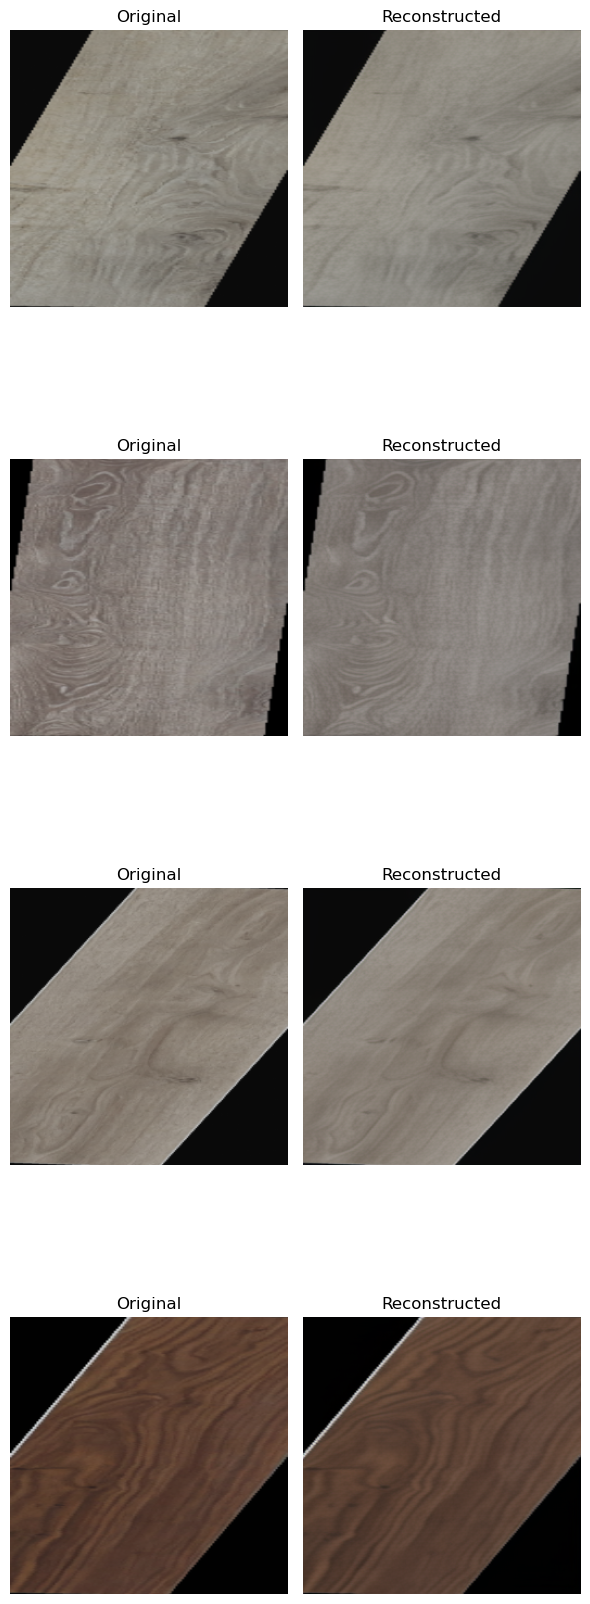

In [15]:
import matplotlib.pyplot as plt

# Switch the model to evaluation mode.
vae.eval()

test_loader = DataLoader(test_data, batch_size=4)

# Compute average reconstruction loss on the test dataset.
test_loss = 0.0
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        # Encode the batch into latent space.
        latent_dist = vae.encode(batch).latent_dist
        latents = latent_dist.sample()
        # Decode the latent representation back to image space.
        recon = vae.decode(latents).sample
        
        # Compute the reconstruction loss (MSE).
        loss = mse(recon, batch)
        test_loss += loss.item() * batch.size(0)

avg_test_loss = test_loss / len(test_data)
print(f"Average Test Loss: {avg_test_loss:.4f}")

# Optional: Visualize some examples.
with torch.no_grad():
    # Get one batch of test images.
    sample_batch = next(iter(test_loader))
    sample_batch = sample_batch.to(device)
    latent_dist = vae.encode(sample_batch).latent_dist
    latents = latent_dist.sample()
    recons = vae.decode(latents).sample

# Move images to CPU for visualization.
sample_batch = sample_batch.cpu().numpy()
recons = recons.cpu().numpy()

# Create a figure to compare original and reconstructed images.
fig, axes = plt.subplots(4, 2, figsize=(6, 18))
for i in range(4):
    # Display original image (undo normalization assuming mean=0.5, std=0.5).
    axes[i, 0].imshow(sample_batch[i].transpose(1, 2, 0) * 0.5 + 0.5)
    axes[i, 0].set_title("Original")
    axes[i, 0].axis('off')
    
    # Display reconstructed image.
    axes[i, 1].imshow(recons[i].transpose(1, 2, 0) * 0.5 + 0.5)
    axes[i, 1].set_title("Reconstructed")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

In [16]:
num_epochs = 100

In [ ]:
from tqdm import tqdm
import os 
# Initialize variables for tracking the best loss
best_loss = float("inf")
best_model_weights = None
early_stopping_counter = 0
patience = 10  # Number of epochs to wait before stopping
save_dir = "../models/vae/"  # Directory to save models

for epoch in range(num_epochs):
    vae.train()
    running_loss = 0.0
    
    # Wrap the train_loader with tqdm for a progress bar
    train_loader_tqdm = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)
    
    for batch in train_loader_tqdm:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        # Encode the input image into the latent space
        latent_dist = vae.encode(batch).latent_dist
        mu, logvar = latent_dist.mean, latent_dist.logvar
        latents = vae.reparameterize(mu, logvar)
        
        # Decode the latent representation back into image space
        recon = vae.decode(latents).sample
        
        # Compute the reconstruction loss
        loss = vae_loss(recon, batch, mu, logvar)
        loss.backward()
        
		# Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(vae.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        # Update the running loss
        running_loss += loss.item()
        
        # Update the progress bar description with the current batch loss
        train_loader_tqdm.set_postfix(loss=loss.item())
    
    # Calculate the average loss for the epoch
    avg_loss = running_loss / len(train_loader)
    
    # Print the average loss for the epoch
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

    # Validation phase
    vae.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            latent_dist = vae.encode(batch).latent_dist
            mu, logvar = latent_dist.mean, latent_dist.logvar
            latents = vae.reparameterize(mu, logvar)
            recon = vae.decode(latents).sample
            val_loss += vae_loss(recon, batch, mu, logvar).item()
    
    avg_val_loss = val_loss / len(test_loader)
    
    if (epoch+1) % 10 == 0:
        vae.save_pretrained(f"{save_dir}/finetuned_vae_percept_{(epoch+1)}")
    
    # Early stopping and model checkpointing
    if avg_val_loss < best_loss:
        print(f"Validation loss improved from {best_loss:.4f} to {avg_val_loss:.4f}")
        best_loss = avg_val_loss
        best_model_weights = vae.state_dict().copy()
        early_stopping_counter = 0
        
    else:
        early_stopping_counter += 1
        print(f"Early stopping counter: {early_stopping_counter}/{patience}")
        if early_stopping_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break


Epoch 1/100, Loss: 0.3176
Validation loss improved from inf to 0.3123
Saved best model at epoch 1


Epoch 2/100, Loss: 0.3160
Validation loss improved from 0.3123 to 0.3078
Saved best model at epoch 2


Epoch 3/100, Loss: 0.3119
Early stopping counter: 1/10


Epoch 4/100, Loss: 0.3105
Validation loss improved from 0.3078 to 0.3066
Saved best model at epoch 4


Epoch 5/100, Loss: 0.3096
Validation loss improved from 0.3066 to 0.3051
Saved best model at epoch 5


Epoch 6/100, Loss: 0.3083
Validation loss improved from 0.3051 to 0.3016
Saved best model at epoch 6


Epoch 7/100, Loss: 0.3058
Early stopping counter: 1/10


Epoch 8/100, Loss: 0.3083
Early stopping counter: 2/10


Epoch 9/100, Loss: 0.3052
Validation loss improved from 0.3016 to 0.2995
Saved best model at epoch 9


Epoch 10/100, Loss: 0.3036


In [22]:
# Save the best model
torch.save({
    'epoch': epoch,
    'model_state_dict': vae.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': best_loss,
}, os.path.join(save_dir, f"best_model_percept_epoch_{epoch+1}.pth"))
print(f"Saved best model at epoch {epoch+1}")

Saved best model at epoch 68


In [20]:
if best_model_weights is not None:
    vae.load_state_dict(best_model_weights)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Average Test Loss: 0.0026


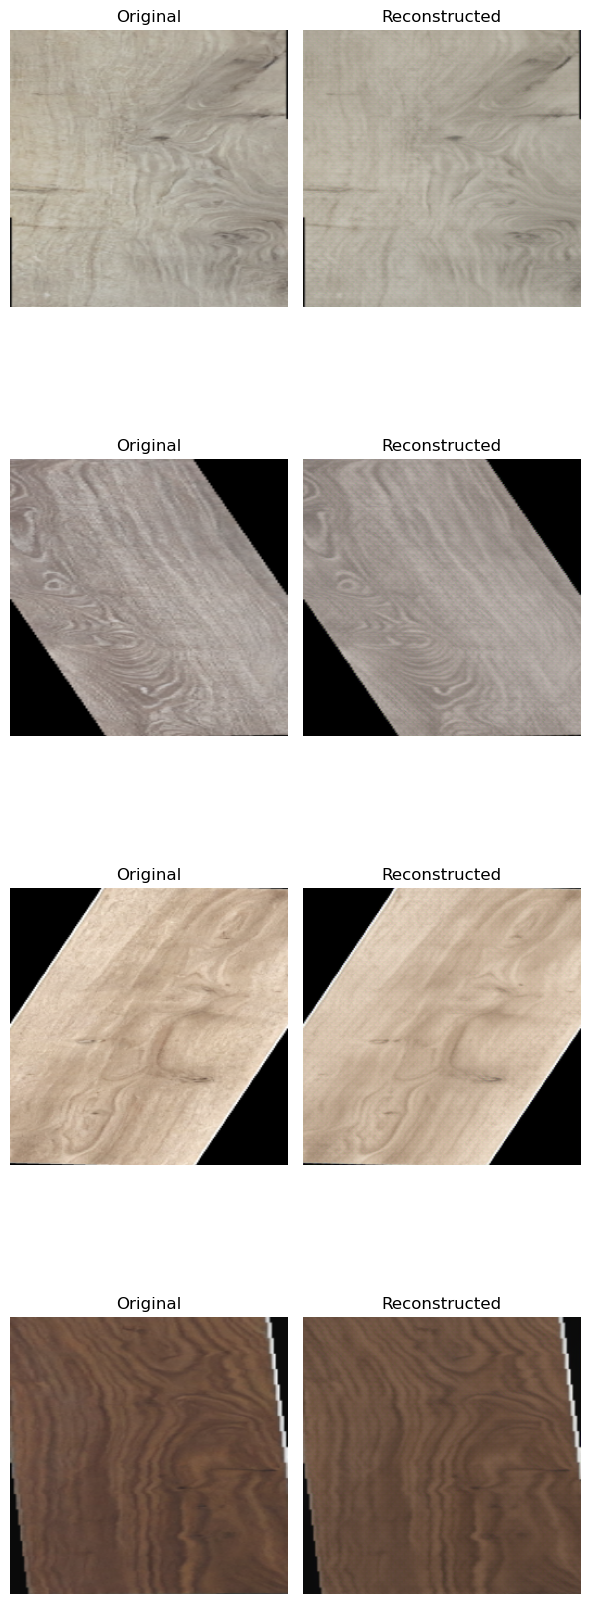

In [21]:
# Switch the model to evaluation mode.
vae.eval()

test_loader = DataLoader(test_data, batch_size=4)

# Compute average reconstruction loss on the test dataset.
test_loss = 0.0
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        # Encode the batch into latent space.
        latent_dist = vae.encode(batch).latent_dist
        latents = latent_dist.sample()
        # Decode the latent representation back to image space.
        recon = vae.decode(latents).sample
        
        # Compute the reconstruction loss (MSE).
        loss = mse(recon, batch)
        test_loss += loss.item() * batch.size(0)

avg_test_loss = test_loss / len(test_data)
print(f"Average Test Loss: {avg_test_loss:.4f}")

# Optional: Visualize some examples.
with torch.no_grad():
    # Get one batch of test images.
    sample_batch = next(iter(test_loader))
    sample_batch = sample_batch.to(device)
    latent_dist = vae.encode(sample_batch).latent_dist
    latents = latent_dist.sample()
    recons = vae.decode(latents).sample

# Move images to CPU for visualization.
sample_batch = sample_batch.cpu().numpy()
recons = recons.cpu().numpy()

# Create a figure to compare original and reconstructed images.
fig, axes = plt.subplots(4, 2, figsize=(6, 18))
for i in range(4):
    # Display original image (undo normalization assuming mean=0.5, std=0.5).
    axes[i, 0].imshow(sample_batch[i].transpose(1, 2, 0) * 0.5 + 0.5)
    axes[i, 0].set_title("Original")
    axes[i, 0].axis('off')
    
    # Display reconstructed image.
    axes[i, 1].imshow(recons[i].transpose(1, 2, 0) * 0.5 + 0.5)
    axes[i, 1].set_title("Reconstructed")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

We obtain that custom VAE still just copies the input picture.